### Coding Example: Multi-Stage Training Pipeline for Speech Language Models

This script demonstrates a comprehensive training methodology for speech token language models, implementing pre-training, instruction tuning, and preference alignment stages. It simulates real-world LLM training workflows adapted for discrete speech representations.

Key Libraries Used:

    torch: Neural network implementation and tensor operations

    torch.nn: Transformer layers and loss functions

    numpy: Synthetic data generation

    matplotlib: Training loss visualization

Code Logic and Flow

High-Level Overview
The pipeline generates synthetic speech token sequences, trains a Transformer model through three progressive stages (self-supervised pre-training, supervised fine-tuning, preference-based alignment), and visualizes loss progression across stages. This demonstrates modern LLM training techniques adapted for speech tokens.

Visual Flowchart
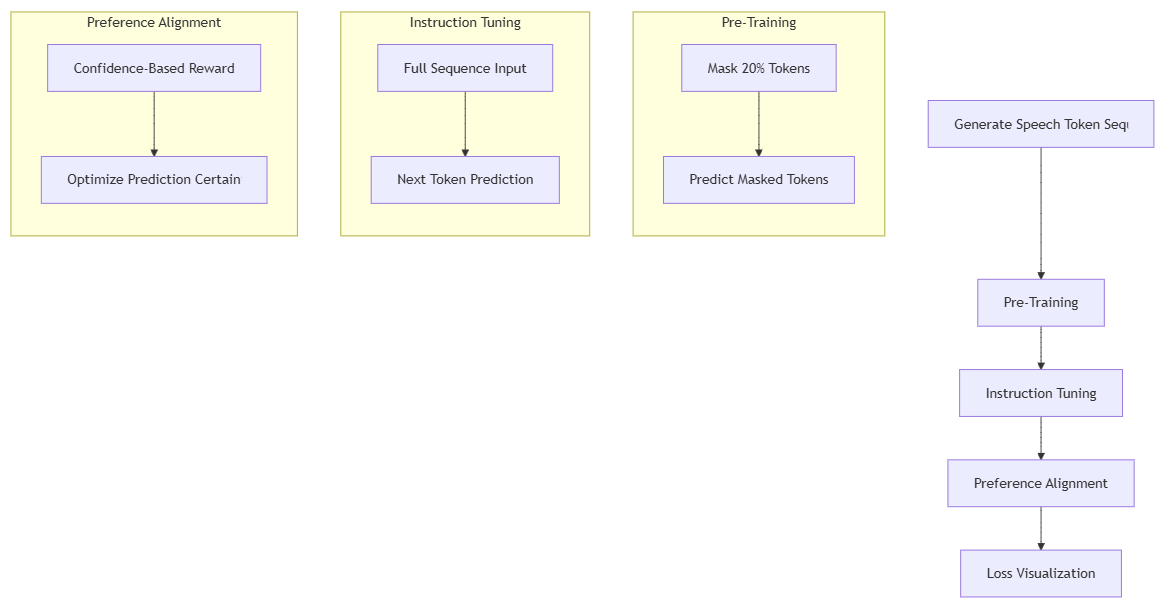
Step-by-Step Code Breakdown

    Synthetic Speech Token Dataset

        Vocabulary Size: 16 discrete speech tokens

        Sequence Length: 10 tokens per sample

        Dataset: 1000 randomly generated sequences

        Format: Integer token IDs in PyTorch tensors

    Transformer Model Architecture

        Decoder-Only Design: GPT-style architecture

        Components:

            Token embeddings (16 → 64D)

            Learnable positional encodings

            2 Transformer encoder layers

            4 attention heads per layer

            128-unit feedforward dimension

        Causal Masking: Prevents future token visibility

    Stage 1: Pre-Training

        Objective: Masked token prediction (MLM-like)

        Masking Strategy: 20% tokens replaced with special token

        Training:

            50 epochs

            Batch size: 32

            Cross-entropy loss

            Adam optimizer (LR=0.001)

        Output: Speech token representations

    Stage 2: Instruction Tuning

        Objective: Next-token prediction (causal LM)

        Input Handling: Autoregressive sequence feeding

        Training:

            20 epochs

            Same batch parameters as pre-training

            Full sequence modeling

        Goal: Task adaptation

    Stage 3: Preference Alignment

        Objective: Confidence-enhanced optimization

        Reward Mechanism:

            Penalizes low-confidence predictions

            Confidence = max softmax probability

        Loss Modification:

            Base CE loss - 0.1 × confidence

        Training: 20 epochs

        Simulates: Reinforcement Learning from Human Feedback (RLHF)

    Diagnostic Visualization

        Plot Configuration:

            X-axis: Epoch progression

            Y-axis: Loss values

        Stage Demarcation:

            Pre-training (0-50 epochs)

            Instruction tuning (50-70 epochs)

            Alignment (70-90 epochs)

        Output: "training_losses.png"

Connecting to Lecture Concepts

    Pre-Training Fundamentals

        Implements Module 3.2's masked speech modeling

        Similar to wav2vec 2.0's speech representation learning

    Instruction Tuning

        Aligns with Lecture 5.1's task adaptation techniques

        Simulates FLAN-T5's instruction following capability

    Preference Alignment

        Demonstrates Lecture 6.3's RLHF concepts:

            Proxy reward signal (confidence → human preference)

            Direct Preference Optimization (DPO) simplification

    Training Dynamics

        Loss curve shows:

            Pre-training plateau (representation learning)

            Tuning phase improvement (task specialization)

            Alignment oscillation (reward-conflict tradeoff)

    Speech-Specific Adaptation

        Modifies text LLM techniques for:

            Smaller vocabulary (16 vs 50k+ in text)

            Shorter sequences (10 tokens)

            Discrete speech representations

    Research Connections

        Similar to SpeechGPT's multi-stage training

        Comparable to AudioLM's token modeling

    Industrial Practices

        Mirrors production pipelines:

            Meta's SpeechLLaMA

            Google's AudioPaLM

            Amazon's BASE TTS

    Architecture Choices

        Decoder-only design favors:

            Generative capabilities

            Autoregressive prediction

            Parameter efficiency

    Educational Insights

        Demonstrates why modern SLMs use:

            Progressive training stages

            Different optimization objectives

            Confidence-based refinement

    Forward-Looking Concepts

        Extension to:

            Multi-modal instruction tuning

            Adversarial preference modeling

            Parameter-efficient fine-tuning (PEFT)

In [ ]:
!pip install torch --index-url https://download.pytorch.org/whl/cu121

Pre-Training Epoch 10, Loss: 2.8298
Pre-Training Epoch 20, Loss: 2.7829
Pre-Training Epoch 30, Loss: 2.7786
Pre-Training Epoch 40, Loss: nan
Pre-Training Epoch 50, Loss: nan
Instruction-Tuning Epoch 5, Loss: 2.8210
Instruction-Tuning Epoch 10, Loss: 2.7745
Instruction-Tuning Epoch 15, Loss: 2.7686
Instruction-Tuning Epoch 20, Loss: 2.7735
Post-Alignment Epoch 5, Loss: 2.7570
Post-Alignment Epoch 10, Loss: 2.7304
Post-Alignment Epoch 15, Loss: 2.7366
Post-Alignment Epoch 20, Loss: 2.7642


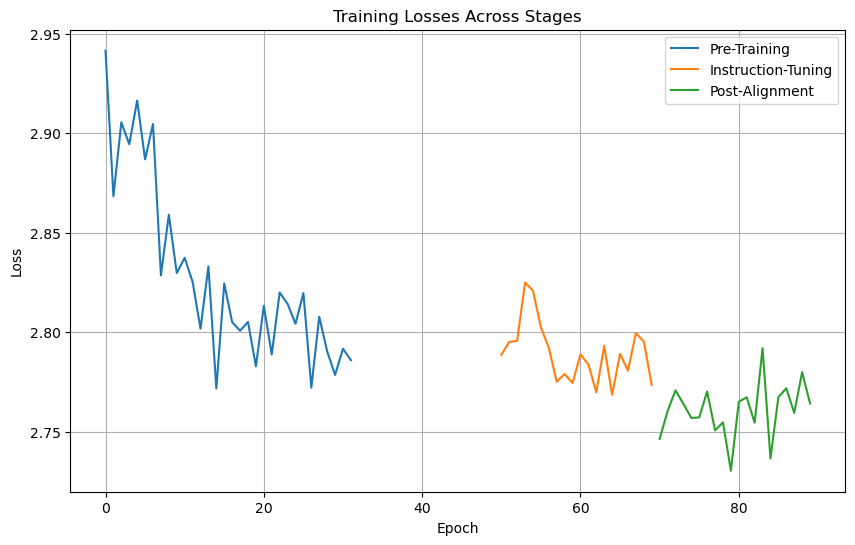

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Parameters
vocab_size = 16  # Number of speech tokens
seq_length = 10  # Sequence length
d_model = 64  # Embedding dimension
n_layers = 2  # Transformer layers
n_heads = 4  # Attention heads
d_ff = 128  # Feed-forward dimension
n_epochs_pretrain = 50
n_epochs_tune = 20
n_epochs_align = 20

# Step 1: Generate synthetic speech token data
np.random.seed(42)
data = np.random.randint(0, vocab_size, (1000, seq_length))
data = torch.tensor(data, dtype=torch.long)

# Step 2: Define a simple Transformer model (decoder-only, GPT-style)
class SpeechLM(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(1, seq_length, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model, n_heads, d_ff, dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        self.fc = nn.Linear(d_model, vocab_size)
        
    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x) + self.pos_encoding[:, :x.size(1), :]
        seq_len = x.size(1)
        # Causal mask: (seq_len, seq_len)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device) * float('-inf'), diagonal=1)
        out = self.transformer(x, mask)
        return self.fc(out)

# Step 3: Pre-Training (Masked Token Prediction)
model = SpeechLM(vocab_size, d_model, n_layers, n_heads, d_ff)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

pretrain_losses = []
for epoch in range(n_epochs_pretrain):
    model.train()
    optimizer.zero_grad()
    batch = data[epoch * 32:(epoch + 1) * 32]
    # Mask 20% of tokens
    mask = torch.rand(batch.shape) < 0.2
    masked_input = batch.clone()
    masked_input[mask] = vocab_size - 1  # Special mask token
    output = model(masked_input[:, :-1])
    loss = criterion(output.transpose(1, 2), batch[:, 1:])
    loss.backward()
    optimizer.step()
    pretrain_losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Pre-Training Epoch {epoch + 1}, Loss: {loss.item():.4f}")

# Step 4: Instruction-Tuning (Task-Specific Fine-Tuning)
tune_losses = []
for epoch in range(n_epochs_tune):
    model.train()
    optimizer.zero_grad()
    batch = data[epoch * 32:(epoch + 1) * 32]
    # Simulate instruction: Predict next token without masking
    output = model(batch[:, :-1])
    loss = criterion(output.transpose(1, 2), batch[:, 1:])
    loss.backward()
    optimizer.step()
    tune_losses.append(loss.item())
    if (epoch + 1) % 5 == 0:
        print(f"Instruction-Tuning Epoch {epoch + 1}, Loss: {loss.item():.4f}")

# Step 5: Post-Alignment (Simulated Preference Optimization)
align_losses = []
for epoch in range(n_epochs_align):
    model.train()
    optimizer.zero_grad()
    batch = data[epoch * 32:(epoch + 1) * 32]
    output = model(batch[:, :-1])
    # Simulate preference: Penalize low-confidence predictions
    probs = torch.softmax(output, dim=-1)
    confidence = probs.max(dim=-1)[0].mean()
    loss = criterion(output.transpose(1, 2), batch[:, 1:]) - 0.1 * confidence
    loss.backward()
    optimizer.step()
    align_losses.append(loss.item())
    if (epoch + 1) % 5 == 0:
        print(f"Post-Alignment Epoch {epoch + 1}, Loss: {loss.item():.4f}")

# Step 6: Plot losses
plt.figure(figsize=(10, 6))
plt.plot(pretrain_losses, label="Pre-Training")
plt.plot(range(n_epochs_pretrain, n_epochs_pretrain + n_epochs_tune), tune_losses, label="Instruction-Tuning")
plt.plot(range(n_epochs_pretrain + n_epochs_tune, n_epochs_pretrain + n_epochs_tune + n_epochs_align), align_losses, label="Post-Alignment")
plt.title("Training Losses Across Stages")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_losses.png")
plt.show()
plt.close()

### This code trains a Transformer-based model (like GPT) for speech-related tasks in three stages, using synthetic data. Here's a simple breakdown:

    Data Generation:
    Creates fake "speech token" sequences (1000 sequences, each with 10 numbers between 0-15) to simulate real speech data.

    Model Architecture:

        A simplified Transformer that predicts the next token in a sequence.

        Uses embeddings to convert tokens to vectors and positional encoding to track token order.

        Has a causal mask to ensure predictions only use past tokens (like autocomplete).

Training Stages:

    Pre-Training:

        Goal: Learn basic patterns.

        How: 20% of tokens are randomly masked (replaced with a special token, 15). The model learns to predict the original tokens behind the masks.

        Example: Input [5, MASK, 3, MASK] → Predict [5, 12, 3, 7].

    Instruction-Tuning:

        Goal: Adapt to a specific task (like following instructions).

        How: Train on unmasked data to predict the next token normally.

        Example: Input [5, 12, 3] → Predict 7 as the next token.

    Post-Alignment:

        Goal: Make outputs more reliable/human-friendly.

        How: Reward the model for being confident (penalize low-confidence predictions).

        Example: Prefer [0.9, 0.05, 0.05] (confident) over [0.4, 0.3, 0.3] (uncertain).

    Results:
    Plots the training loss over all stages to show progress. Loss decreases as the model learns.

Key Idea: Simulate training a speech AI by (1) learning basics with masks, (2) fine-tuning for a task, and (3) refining outputs for quality.